# Visualising 2D Vectors with Matplotlib

A 2D vector is a mathematical pair $(x, y)$ that represents both **direction** and **magnitude**. 
In data science and physics, we represent vectors visually as arrows pointing from the origin $(0,0)$ to the terminal coordinate $(x, y)$. 

Using arrows is crucial because the length of the arrow represents the **magnitude** (strength), while the pointing tip shows the **direction**.

---

### Core Syntax: `plt.arrow()`

To plot vectors as arrows, Matplotlib provides the `plt.arrow(x, y, dx, dy, **kwargs)` function. It uses the following primary components:

* **Starting Point (`x`, `y`)**: The base position of the arrow (typically `0, 0` for standard vectors).
* **Vector Components (`dx`, `dy`)**: The horizontal and vertical displacement of the vector.
* **Arrowhead Control (`head_width`, `head_length`)**: Essential parameters to make the arrowhead visible and scalable.
* **Styling (`color`)**: An optional parameter to differentiate multiple vectors visually.



In [5]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


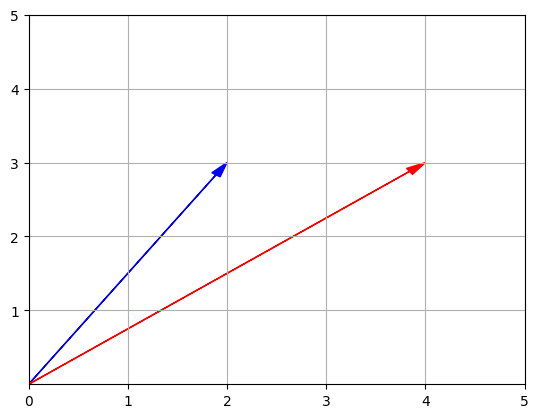

In [2]:
#Implementaion Example
 
#Starting point
x,y=0,0

#defining the 2-D vector component
dx,dy=2,3

#vector plot using plot.arrow()
plt.arrow(x,y,dx,dy,head_width=0.1,head_length=0.2,color='blue',length_includes_head=True)
plt.arrow(x,y,4,3,head_width=0.1,head_length=0.2,color='red',length_includes_head=True)

#configuring the grid and display limits
plt.xlim(0,5)
plt.ylim(0,5)

plt.grid(True)

# Manually setting ticks to prevent duplicate zeros at the origin
plt.xticks([0, 1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4,5]) # Left out 0 so it doesn't double print



plt.axhline(0,color='black',lw=0.5)
plt.axhline(0,xmin=0,xmax=1,color='black',lw=0.5)
plt.show()

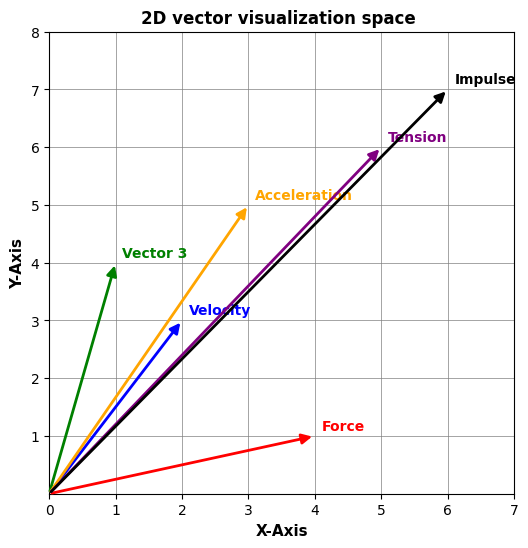

In [3]:
"""
plt.arrow() is known to distort if you change the figure window size.
For plotting vectors, using plt.annotate() is highly recommended because 
it is more stable and automatically handles the arrowhead alignment perfectly:

"""

import matplotlib.pyplot as plt

def plot_multiple_vectors(vectors):
  
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Pre-defined list of distinct colors to cycle through
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']
    
    max_x, max_y = 1, 1 # Track limits to scale graph dynamically
    
    for i, v in enumerate(vectors):#(index,item)
        color = colors[i % len(colors)]
        
        # Extract components dynamically based on input format
        if len(v) == 4:
            dx, dy, label,color = v
        elif len(v)==3:
            dx,dy,label=v    
        else:
            dx, dy = v
            label = f'Vector {i+1}'
        
        # 1. Draw the vector arrow
        ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=color, mutation_scale=15, lw=2))
        
        # 2. Add text label offset slightly from the tip
        ax.text(dx + 0.1, dy + 0.1, label, color=color, fontsize=10, fontweight='bold')
        
        # Track maximum limits for axis scaling
        max_x = max(max_x, dx)
        max_y = max(max_y, dy)

    # Dynamic limits configuration (adds padding so tips aren't cut off)
    ax.set_xlim(0, max_x + 1)
    ax.set_ylim(0, max_y + 1)
    ax.grid(True, linestyle='-', linewidth=0.5, color='gray')

    # Remove overlapping zero at origin
    ax.set_xticks(range(int(max_x) + 2))
    ax.set_yticks([i for i in range(int(max_y) + 2) if i != 0])
    
    #Lables and title
    ax.set_title("2D vector visualization space ",fontsize=12,fontweight='bold')
    ax.set_xlabel("X-Axis",fontsize=11,fontweight='bold')
    ax.set_ylabel("Y-Axis",fontsize=11,fontweight='bold')
    
    plt.show()


my_vectors = [
    (2, 3, "Velocity"),
    (4, 1, "Force"),
    (1, 4),             # Auto-labelled as Vector 3
    (3, 5, "Acceleration"),
    (5,6,"Tension"),
    (6,7,"Impulse","black")
]

plot_multiple_vectors(my_vectors)
 

## The Theory: Vector Addition

Vector addition is the process of combining two or more vectors to create a new vector, called the **resultant** or **sum**.

### Mathematical Definition
To add vectors algebraically, you simply add their corresponding components. If you have three vectors $\vec{v} = (x_1, y_1)$, $\vec{w} = (x_2, y_2)$, and $\vec{z} = (x_3, y_3)$, the sum vector $\vec{R}$ is:

$$\vec{R} = \vec{v} + \vec{w} + \vec{z} = (x_1 + x_2 + x_3, y_1 + y_2 + y_3)$$

### Geometric Interpretation: The Head-to-Tail Method
Visually, vector addition is performed using the **head-to-tail** (or tip-to-tail) method. 

1. **Step-by-Step Path:** Start at the origin $(0,0)$ and draw the first vector. Then, place the tail (start) of the second vector exactly at the head (tip) of the first vector. Continue this chain for all vectors.
2. **The Resultant (Sum):** The final sum vector is drawn straight from the starting point (the origin) to the head of the very last vector in the chain. 

**In this example:** The code below takes a sequence of vectors and connects them head-to-tail. The final entry triggers the code to draw the "Sum" vector, which represents the direct path from the origin to the final destination, proving that adding vectors is like chaining multiple movements together to find the net displacement.

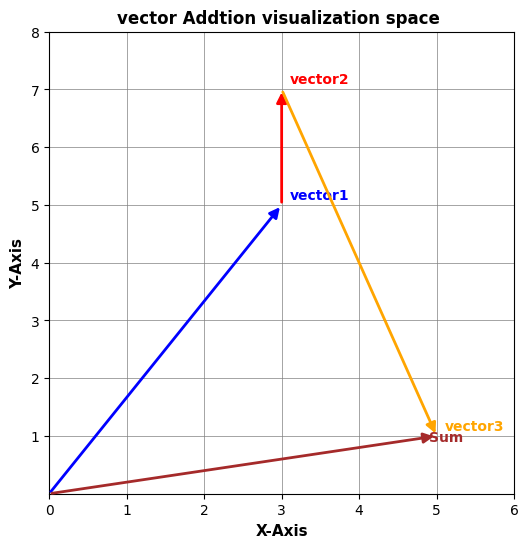

In [6]:
def plot_add(vector):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    #set of pre-defined colors
    colours=['blue','red','orange','brown','pink','purple','cyan']
    #Track limit to scale the graph
    max_x,max_y=1,1
     
    #staring point
    x,y=0,0 
    for i,v in enumerate(vector):
        
        if len(v)==3:
            dx,dy,label=v 
        else:
            dx,dy=v 
            label=f"vector{i+1}"
        color=colours[i% len(colours)]
        
        #label vectors
        x_name_cor=dx + 0.1
        y_name_cor=dy + 0.1
        
        #For last Sum vector
        if i==len(vector)-1:
            dx,dy=x,y
            x,y=0,0
            label="Sum"
            x_name_cor=dx - 0.1
            y_name_cor=dy - 0.1
                
        ax.annotate('',xy=(dx,dy),xytext=(x,y),arrowprops=dict(arrowstyle='-|>',color=color, mutation_scale=15,lw=2 ))
        ax.text(x_name_cor, y_name_cor , label, color=color, fontsize=10, fontweight='bold')
        x,y=dx,dy
                
        max_x=max(max_x,dx)
        max_y=max(max_y,dy)
        
    # Dynamic limits configuration (adds padding so tips aren't cut off)
    ax.set_xlim(0, max_x + 1)
    ax.set_ylim(0, max_y + 1)
    ax.grid(True, linestyle='-', linewidth=0.5, color='gray')

    # Remove overlapping zero at origin
    ax.set_xticks(range(int(max_x) + 2))
    ax.set_yticks([i for i in range(int(max_y) + 2) if i != 0])
    
    #Lables and title
    ax.set_title("vector Addtion visualization space ",fontsize=12,fontweight='bold')
    ax.set_xlabel("X-Axis",fontsize=11,fontweight='bold')
    ax.set_ylabel("Y-Axis",fontsize=11,fontweight='bold')
    
    plt.show()
     
     
#List of vectors to add in sequence
v=(3,5)
w=(3,7)
z=(5,1)

vector_add=[v,w,z,(0,0)]

plot_add(vector_add)

    
    

## The Theory: Scalar Multiplication of Vectors

When you multiply a vector by a regular number (called a **scalar**), you are performing **scalar multiplication**. This operation changes the length (magnitude) of the vector, but if the scalar is positive, the vector's direction remains exactly the same.

### Mathematical Definition
If you have a 2D vector $\vec{v}$ with components $(x, y)$ and a scalar $m$, the scaled vector is calculated by multiplying each individual component by that scalar:

$$m\vec{v} = (m \cdot x, m \cdot y)$$

### Geometric Interpretation
Visually, multiplying by a scalar simply stretches or shrinks the vector arrow:
*   **$m > 1$:** The vector stretches and gets longer (like in the code below, where $m=2$).
*   **$0 < m < 1$:** The vector shrinks and gets shorter.
*   **$m < 0$:** The vector scales in length *and* flips to point in the exact opposite direction.

**In this example:** We start with an initial vector $\vec{v} = (3, 4)$. By applying a multiplier of $m = 2$, we generate a new, scaled vector $(6, 8)$. Because they point in the exact same direction, the red scaled vector will directly overlap the blue original vector, extending exactly twice as far.

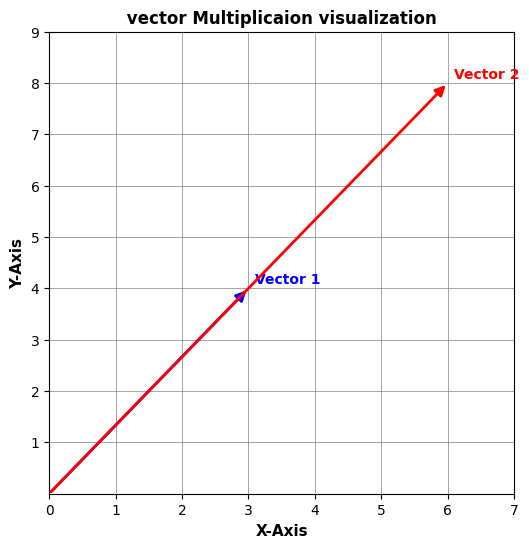

In [15]:
def plot_multiplication(vectors):
  
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Track limits to scale graph dynamically
    max_x, max_y = 1, 1 
    
    for i, v in enumerate(vectors):#(index,item)
        
        color = ['blue', 'red']
            
        # Extract components
        dx,dy=v
            
        label = f'Vector {i+1}'
        
        # 1. Draw the vector arrow
        ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=color[i], mutation_scale=15, lw=2))
        
        # 2. Add text label offset slightly from the tip
        ax.text(dx + 0.1, dy + 0.1, label, color=color[i], fontsize=10, fontweight='bold')
        
        # Track maximum limits for axis scaling
        max_x = max(max_x, dx)
        max_y = max(max_y, dy)

    # Dynamic limits configuration (adds padding so tips aren't cut off)
    ax.set_xlim(0, max_x + 1)
    ax.set_ylim(0, max_y + 1)
    ax.grid(True, linestyle='-', linewidth=0.5, color='gray')

    # Remove overlapping zero at origin
    ax.set_xticks(range(int(max_x) + 2))
    ax.set_yticks([i for i in range(int(max_y) + 2) if i != 0])
    
    #Lables and title
    ax.set_title(" vector Multiplicaion visualization ",fontsize=12,fontweight='bold')
    ax.set_xlabel("X-Axis",fontsize=11,fontweight='bold')
    ax.set_ylabel("Y-Axis",fontsize=11,fontweight='bold')
    
    plt.show()
    

#Given vector
v = ( 3, 4)
#Multiplier
m = 2
#scaled vector
scaled_v = tuple(item * m for item in v)

vector_mul=[(v),(scaled_v)]
plot_multiplication(vector_mul)
    
    
    
    


## Orthogonal Vectors & The Dot Product

Two vectors are considered **orthogonal** (or perpendicular) if they intersect at exactly a 90-degree angle ($\frac{\pi}{2}$ radians). 

Mathematically, the most efficient way to determine if two vectors are orthogonal is by calculating their **dot product** (also known as the inner product). If the dot product of two non-zero vectors is exactly zero, the vectors are orthogonal.

### Mathematical Definition
For two vectors $\vec{v}$ and $\vec{w}$ in an $n$-dimensional space, the dot product algebraically is the sum of the products of their corresponding entries:

$$ \vec{v} \cdot \vec{w} = \sum_{i=1}^{n} v_i w_i = v_1 w_1 + v_2 w_2 + \dots + v_n w_n $$

Geometrically, the dot product relates to the angle ($\theta$) between the vectors:

$$ \vec{v} \cdot \vec{w} = \|\vec{v}\| \|\vec{w}\| \cos(\theta) $$

Because $\cos(90^\circ) = 0$, the right side of the equation evaluates to $0$ when the vectors are perpendicular. Therefore:
$$ \vec{v} \cdot \vec{w} = 0 \iff \vec{v} \perp \vec{w} $$

### Implementation Notes
* **Handling Floating-Point Errors (`tol`):** In theoretical math, we simply check if the dot product equals `0`. However, computers use floating-point arithmetic, which can introduce microscopic rounding errors (e.g., returning `1.12e-16` instead of exactly `0.0`). Instead of a strict equality (`== 0`), our code checks if the absolute value of the dot product is smaller than a tiny tolerance (`tol = 1e-10`). 


In [25]:
def are_orthogonal(v, w, tol=1e-10):
    if len(v) != len(w):
        raise ValueError("Vectors must have the same length")
    dot = np.dot(v, w)
    return abs(dot) < tol

#vectors 
v = np.array([2, 3])
w = np.array([-3, 2])

try:
    if are_orthogonal(v, w):
        print("Vectors are orthogonal!")
    else:
        print("Vectors are not orthogonal")
except ValueError as e:
    print(e)




Vectors are orthogonal!


## Vector Projection

**Vector projection** is a way to find out how much of one vector goes in the direction of another. Geometrically, you can think of it as the "shadow" that vector $\vec{v}$ casts onto vector $\vec{u}$ if a light source were shining exactly perpendicular to $\vec{u}$.

### Mathematical Definition
The orthogonal projection of vector $\vec{v}$ onto vector $\vec{u}$ (often written as $\text{proj}_{\vec{u}}\vec{v}$) is calculated using the dot product:

$$ \text{proj}_{\vec{u}}\vec{v} = \left( \frac{\vec{v} \cdot \vec{u}}{\vec{u} \cdot \vec{u}} \right) \vec{u} $$





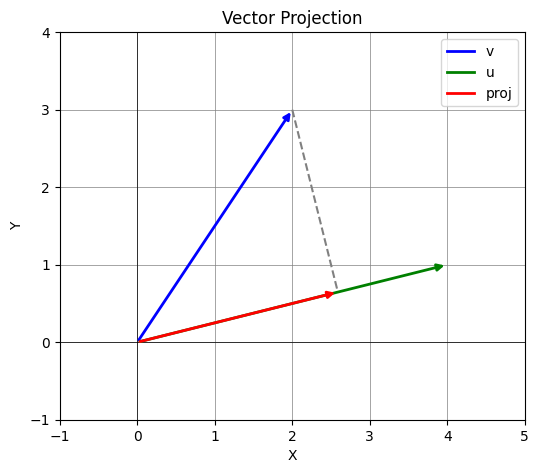

Projection: [2.588 0.647]


In [10]:


def projection(v, u):
    v, u = np.asarray(v), np.asarray(u)
    if v.shape != u.shape:
        raise ValueError("Vectors must have the same shape")
        
    sqr_u = np.dot(u, u)
    if sqr_u == 0:
        raise ValueError("Cannot project onto the zero vector")

    # projection
    proj = (np.dot(v, u) / sqr_u) * u

    fig, ax = plt.subplots(figsize=(6, 6))

    # Looped Plotting Section
    vectors = [(v, 'blue', 'v'), (u, 'green', 'u'), (proj, 'red', 'proj')]
    
    for vec, color, name in vectors:
        # Draw arrows
        ax.annotate('', xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=2))
        
    # Legend generated cleanly via list comprehensions
    ax.legend([Line2D([0], [0], color=c, lw=2) for _, c, _ in vectors],
              [n for _, _, n in vectors])

    # Dashed line from tip of v to its projection
    ax.plot([v[0], proj[0]], [v[1], proj[1]], 'gray', linestyle='--')

    # Condensed axis limits and padding using numpy
    pts = np.vstack([[0, 0], v, u, proj])
    pad_x = max(1.0, np.ptp(pts[:, 0]) * 0.2)
    pad_y = max(1.0, np.ptp(pts[:, 1]) * 0.2)
    
    ax.set(xlim=(pts[:, 0].min() - pad_x, pts[:, 0].max() + pad_x),
           ylim=(pts[:, 1].min() - pad_y, pts[:, 1].max() + pad_y),
           aspect='equal', xlabel='X', ylabel='Y', title='Vector Projection')

    ax.grid(True, linestyle='-', linewidth=0.5, color='gray')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    
    plt.show()
    return proj

# Example usage
v = np.array([2, 3])
u = np.array([ 4,1,])


try:
    proj = projection(v, u)
    print('Projection:', np.round(proj, 3))
except ValueError as e:
    print(f"Error : {e}")
